# Skeletal Variation


The comparison of skeletons across species lead to historical insights in evolutionary biology. In this project, we will explore the bones of the human body and make comparisons to a wide variety of mammals and birds.


### Loading the Data

The file `'adult-human-skeleton.csv'` contains information about every bone in the human body. 



In [16]:
import pandas as pd
df = pd.read_csv('adult-human-skeleton.csv')
df 

,name,region,subregion,side,fused_from
0,frontal,head,cranium,center,2
1,left parietal,head,cranium,left,1
2,right parietal,head,cranium,right,1
3,left temporal,head,cranium,left,1
4,right temporal,head,cranium,right,1
...,...,...,...,...,...
201,right distal pedal phalanx 1,foot,toes,right,1
202,right distal pedal phalanx 2,foot,toes,right,1
203,right distal pedal phalanx 3,foot,toes,right,1
204,right distal pedal phalanx 4,foot,toes,right,1


Each row represents one bone in the adult human body. We can see that adults have 206 bones. What can we learn about these bones?

### Claim: Half the bones are in the hands and feet

You might have heard the claim that over half the bones in your body are found in your hands and feet. Is this claim true or is it an urban legend?

Let's see how many bones are in each region .


In [4]:
df['region'].value_counts()

region
hand     54
foot     52
torso    50
head     28
neck      8
leg       8
arm       6
Name: count, dtype: int64

The hands have a total of 54 bones ,and the feet have 52 bones.

Earlier we saw that the entire body has 206 bones. Using python, we can calculate what proportion are in the hands and feet. Run the code below:

In [5]:
(54 + 52) / 206

0.5145631067961165

Over 51% of bones are found in the hands and feet. The claim is true!

### Baby bones

Infants have more bones than adults, but as the baby develops, groups of bones fuse together. This is detailed in the `'fused_from'` column of our data.

Let's sort the values in this `'fused_from'` column.


In [6]:
df.sort_values(by='fused_from', ascending=False)

,name,region,subregion,side,fused_from
40,sternum,torso,chest,center,6
30,c2,neck,vertebra,center,5
82,sacrum,torso,pelvis,center,5
5,occipital,head,cranium,center,4
83,coccyx,torso,pelvis,center,4
...,...,...,...,...,...
201,right distal pedal phalanx 1,foot,toes,right,1
202,right distal pedal phalanx 2,foot,toes,right,1
203,right distal pedal phalanx 3,foot,toes,right,1
204,right distal pedal phalanx 4,foot,toes,right,1


This shows a wide variety of bone fusion across the body. For example, the sternum is formed from the fusion of 6 bones.

Before all this fusion takes place, how many bones do infants have?


In [7]:
df['fused_from'].sum()

np.int64(305)

Human infants have 305 bones, many of which fuse together, resulting in 206 bones in the adult body.

### Human neck bones

Necks are quite flexible. How many bones are in the human neck to allow for that flexibility?

In [8]:
df.query('region == "neck"')

,name,region,subregion,side,fused_from
28,hyoid,neck,throat,center,3
29,c1,neck,vertebra,center,3
30,c2,neck,vertebra,center,5
31,c3,neck,vertebra,center,3
32,c4,neck,vertebra,center,3
33,c5,neck,vertebra,center,3
34,c6,neck,vertebra,center,3
35,c7,neck,vertebra,center,3


The neck has 1 throat bone, and a stack of 7 neck vertebrae, named C1 through C7. The "C" stands for cervical, meaning neck. These 7 cervical vertebrae form the top of the spinal column.

So, humans have 7 neck vertebrae. What about other mammals?

### Mammal neck bones

This project includes the <code>'mammal-neck-bones.csv'</code> file. Let's load it so we can explore the necks of other mammals.

In [9]:
mammals = pd.read_csv('mammal-neck-bones.csv')
mammals

,species,neck_vertebrae
0,cheetah,7
1,impala,7
2,giant panda,7
3,hartebeest,7
4,moose,7
...,...,...
297,alpaca,7
298,common wombat,7
299,red fox,7
300,fennec fox,7


The rows shown above all have 7 neck vertebrae, but is this true for all 302 mammals in this dataset? Let's find the data for giraffes, which we know have really long necks.

In [10]:
mammals.query('species == "giraffe"')

,species,neck_vertebrae
108,giraffe,7


Despite their very long necks, giraffes also have 7 neck vertebrae!

So, do all mammals have 7 vertebrae?

In [11]:
mammals.query('neck_vertebrae != 7')

,species,neck_vertebrae
27,pale-throated sloth,9
28,brown-throated sloth,9
60,hoffmann's two-toed sloth,6
291,west indian manatee,6


Aha! It looks like the only mammals without 7 vertebrae are manatees and sloths.

### Bird neck bones

While mammals mostly have 7 neck vertebrae, what about birds? Let's load in `'bird-neck-bones.csv'` to explore.


In [12]:
birds = pd.read_csv('bird-neck-bones.csv')
birds

,species,neck_vertebrae
0,cinereous vulture,13
1,guineafowl,14
2,red-legged partridge,14
3,blue-cheeked parrot,12
4,northern pintail,15
...,...,...
76,barn owl,12
77,eurasian hoopoe,13
78,murre,13
79,new zealand rockwren,13


Birds seem to have many more vertebrae than mammals. Let's make a bar plot of the value counts to get a sense of the distribution.


<Axes: xlabel='neck_vertebrae'>

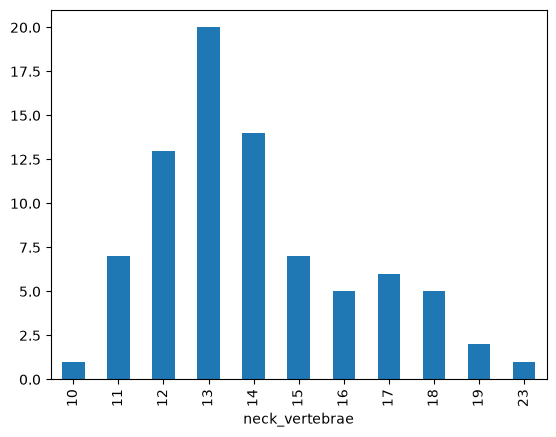

In [13]:
bird_counts = birds['neck_vertebrae'].value_counts()
bird_counts = bird_counts.sort_index()
bird_counts.plot.bar()


Birds have more diverse neck skeletons.

The most common number of neck vertebrae is 13, but it looks like 23 is the maximum.


In [14]:
birds.query('neck_vertebrae == neck_vertebrae.max()')

,species,neck_vertebrae
28,mute swan,23


The beautiful Mute Swan takes the prize!

## Project extensions


### Extension 1: Which bird has the fewest neck vertebrae?

In [17]:
birds.query('neck_vertebrae == neck_vertebrae.min()')

,species,neck_vertebrae
11,blue-and-yellow macaw,10


The result shows that the **blue-and-yellow macaw** has only 10 neck vertebrae, which is the fewest in this dataset, though still more than the 7 vertebrae found in most mammals.

### Extension 2: Do humans have more bones in the arms or legs?

In [18]:
arm_bones = df.query('region == "arm"')
leg_bones = df.query('region == "leg"')

print(f"Number of arm bones: {len(arm_bones)}")
print(f"Number of leg bones: {len(leg_bones)}")

Number of arm bones: 6
Number of leg bones: 8


we found that humans have **6 arm bones** and **8 leg bones**. This indicates that the lower limbs have a slightly higher count of major bones compared to the upper limbs.

### Extension 3: How many ribs do humans have?

In [19]:
ribs = df[df['name'].str.contains("rib")]
display(ribs)

print(f"Total number of ribs: {ribs.shape[0]}")

,name,region,subregion,side,fused_from
41,left rib 1,torso,chest,left,1
42,left rib 2,torso,chest,left,1
43,left rib 3,torso,chest,left,1
44,left rib 4,torso,chest,left,1
45,left rib 5,torso,chest,left,1
46,left rib 6,torso,chest,left,1
47,left rib 7,torso,chest,left,1
48,left rib 8,torso,chest,left,1
49,left rib 9,torso,chest,left,1
50,left rib 10,torso,chest,left,1


Total number of ribs: 24


 we isolated all rows related to ribs. The result confirms that a standard adult human has **24 ribs** (12 pairs), which make up a significant portion of the torso's 50 total bones.

# Conclusion
In this project, we explored the biological variation of skeletons:
- **Humans:** We verified that over 50% of human bones are in the hands and feet and that infants start with significantly more bones (305) than adults (206) due to fusion.
- **Mammals:** We discovered a strong evolutionary consistency where almost all mammals (including giraffes) have 7 neck vertebrae, with rare exceptions like sloths and manatees.
- **Birds:** We observed much higher neck flexibility and variation, with counts ranging from 10 to 23 vertebrae.

This data highlights how skeletal structures are adapted to the specific needs of different species while often retaining conserved evolutionary traits.